# **Exploratory Data Analysis**

This dataset belongs to a leading online E-commerce company. The company wants to identify customers who are likely to churn, so they can proactively approach these customers with promotional offers.



The dataset contains various features related to customer behavior and characteristics, which can be used to predict customer churn.



---

## **Data Overview**

### Data Import

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_pickle("..//data/cleaned_data.pickle")
df = data.copy()
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,Satisfaction_Label,Address_status,Cashback_status
0,15,29,4,Laptop & Accessory,3,Single,2,0,7,143.32,0,Neutral,1-5,Medium (100-300$)
1,7,25,4,Mobile,1,Married,2,0,7,129.29,0,Bad,1-5,Medium (100-300$)
2,27,13,3,Laptop & Accessory,1,Married,5,0,7,168.54,0,Bad,1-5,Medium (100-300$)
3,20,25,4,Fashion,3,Divorced,7,0,3,230.27,0,Neutral,6-10,Medium (100-300$)
4,30,15,4,Others,4,Single,8,0,8,322.17,0,Good,6-10,Major (300$+)


### No. of Rows and Columns

In [ ]:
# df.shape[0]
print(f"No. of ROWS: {df.shape[0]}", \
    f"No. of COLUMNS: {df.shape[1]}", sep = '\n')

No. of ROWS: 3937
No. of COLUMNS: 14


### Data Types

In [ ]:
num_cols = df.select_dtypes(include=['int32', 'int64', 'float64']).columns.to_list()
cat_cols = df.select_dtypes(include=['category']).columns.to_list()

print(f"Numerical columns ({len(num_cols)}): {', '.join(num_cols)}")
print(f"Categorical columns ({len(cat_cols)}): {', '.join(cat_cols)}")

Numerical columns (9): Tenure, WarehouseToHome, NumberOfDeviceRegistered, SatisfactionScore, NumberOfAddress, Complain, DaySinceLastOrder, CashbackAmount, Churn
Categorical columns (5): PreferedOrderCat, MaritalStatus, Satisfaction_Label, Address_status, Cashback_status


In [ ]:
print(f"The Data Types are: {', '.join([i for i in df.dtypes.astype('str').rename('Data Type').unique()])}")

The Data Types are: int32, int64, category, float64


### Data Types per Columns

In [ ]:
df.dtypes.astype('str').rename('Data Type').sort_values(ascending = False)

NumberOfDeviceRegistered       int64
SatisfactionScore              int64
NumberOfAddress                int64
Complain                       int64
Churn                          int64
Tenure                         int32
WarehouseToHome                int32
DaySinceLastOrder              int32
CashbackAmount               float64
PreferedOrderCat            category
MaritalStatus               category
Satisfaction_Label          category
Address_status              category
Cashback_status             category
Name: Data Type, dtype: object

* Besides **int**, **float** and **category** there are no other data types. 

### General Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3937 entries, 0 to 3936
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Tenure                    3937 non-null   int32   
 1   WarehouseToHome           3937 non-null   int32   
 2   NumberOfDeviceRegistered  3937 non-null   int64   
 3   PreferedOrderCat          3937 non-null   category
 4   SatisfactionScore         3937 non-null   int64   
 5   MaritalStatus             3937 non-null   category
 6   NumberOfAddress           3937 non-null   int64   
 7   Complain                  3937 non-null   int64   
 8   DaySinceLastOrder         3937 non-null   int32   
 9   CashbackAmount            3937 non-null   float64 
 10  Churn                     3937 non-null   int64   
 11  Satisfaction_Label        3937 non-null   category
 12  Address_status            3937 non-null   category
 13  Cashback_status           3937 non-null   catego

### Summary of Data Types 

In [ ]:
df.dtypes.astype('str').value_counts()

int64       5
category    5
int32       3
float64     1
Name: count, dtype: int64

---

## **Missing Values & Duplicates**

Missing and duplicated data were handled in the previous preprocessing step. The EDA is performed on the cleaned (3.937) rows.

---

## **Numerical Data**

**Numerical values** are data expressed as numbers rather than categories. They represent measurable quantities and allow for mathematical calculations such as mean, median or sum.

In [ ]:
df.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000,3937.000000
mean,10.023114,15.552959,3.679451,3.088646,4.225298,0.282449,4.451359,176.723553,0.170942
std,8.290381,8.086757,1.014312,1.381871,2.588336,0.450248,3.584524,48.807396,0.376506
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.700000,0.000000
50%,9.000000,14.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.340000,0.000000
75%,15.000000,20.000000,4.000000,4.000000,6.000000,1.000000,7.000000,195.260000,0.000000
max,61.000000,36.000000,6.000000,5.000000,11.000000,1.000000,46.000000,324.990000,1.000000


### General Skewness

In [ ]:
general_skew = df[num_cols].skew().rename('Skewness').sort_values()
general_skew

NumberOfDeviceRegistered   -0.410240
SatisfactionScore          -0.163815
Tenure                      0.828744
WarehouseToHome             0.935321
NumberOfAddress             0.953144
Complain                    0.966855
CashbackAmount              1.142611
DaySinceLastOrder           1.420279
Churn                       1.748841
Name: Skewness, dtype: float64

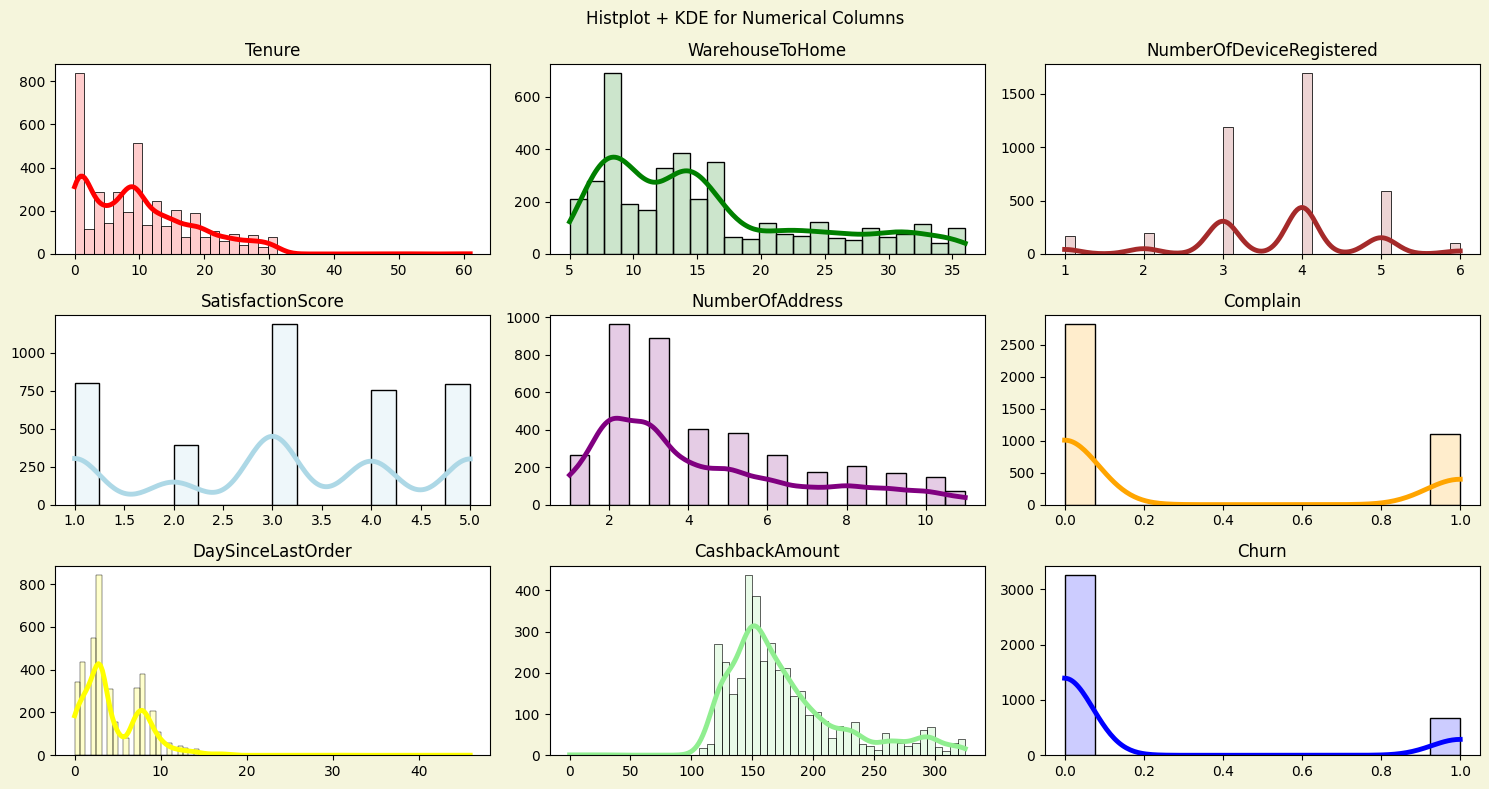

In [ ]:
fig, axes = plt.subplots(3, 3, figsize = (15, 8), facecolor = 'beige')
axes = axes.flatten() # is a method used to convert a multi-dimensional array of subplots into a one-dimensional (1D) array
colors, c = ['red', 'green', 'brown', 'lightblue', 'purple', 'orange', 'yellow', 'lightgreen', 'blue'], 0

for ax, col in zip(axes, num_cols): # zip() takes the first item from each list and pairs them
    subset = df[col]
    sns.histplot(subset, ax = ax, color = colors[c], kde = True, alpha = .2, line_kws = {'linewidth':3.5})
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(col)
    c += 1

plt.suptitle('Histplot + KDE for Numerical Columns')
plt.tight_layout()
plt.savefig('../figures/histplot_kde.png', dpi=300, bbox_inches='tight')
plt.show()


#### Moderately skewed Columns

* `NumberOfDeviceRegistered` and `SatisfactionScore` show negative skewness between (-0.5, 0) which means they are fairly symmetrical.

* `Tenure`, `WarehouseToHome` and `NumberOfAddress` have positive values between (0.5, 1) which means they are moderately right-skewed.

* `Complain` (binary) also shows moderate positive skewness, reflecting that the majority of customers did not file a complaint. 

In [ ]:
general_skew[general_skew < 1]

NumberOfDeviceRegistered   -0.410240
SatisfactionScore          -0.163815
Tenure                      0.828744
WarehouseToHome             0.935321
NumberOfAddress             0.953144
Complain                    0.966855
Name: Skewness, dtype: float64

There are approximately 2.5 times more customers who did not file a complaint (0) than those who did (1).

In [ ]:
df.Complain.value_counts()

Complain
0    2825
1    1112
Name: count, dtype: int64

#### Significantly skewed Columns

* `CashbackAmount` and `DaySinceLastOrder` show positive skewness greater than 1, indicating they are highly right-skewed. This suggests the presence of outliers that may require further investigation using the IQR method.
* `Churn` (binary) also shows significant positive skewness (~ 1.74). This reflects the class imbalance in the dataset: 82% of customers (3.258) did not leave, while 18% (672) churned. 

In [ ]:
general_skew[general_skew >= 1]

CashbackAmount       1.142611
DaySinceLastOrder    1.420279
Churn                1.748841
Name: Skewness, dtype: float64

In [ ]:
df.Churn.value_counts()

Churn
0    3264
1     673
Name: count, dtype: int64

#### **IQR - Outliers**

We are going to check the boxplots for the higher-skewed columns that have their absolute value of the skewness between 0.41 and 1.42. (The `Churn` field is not going to be analyzed since it has only 2 values, therefore it cannot tell us any specific information.)

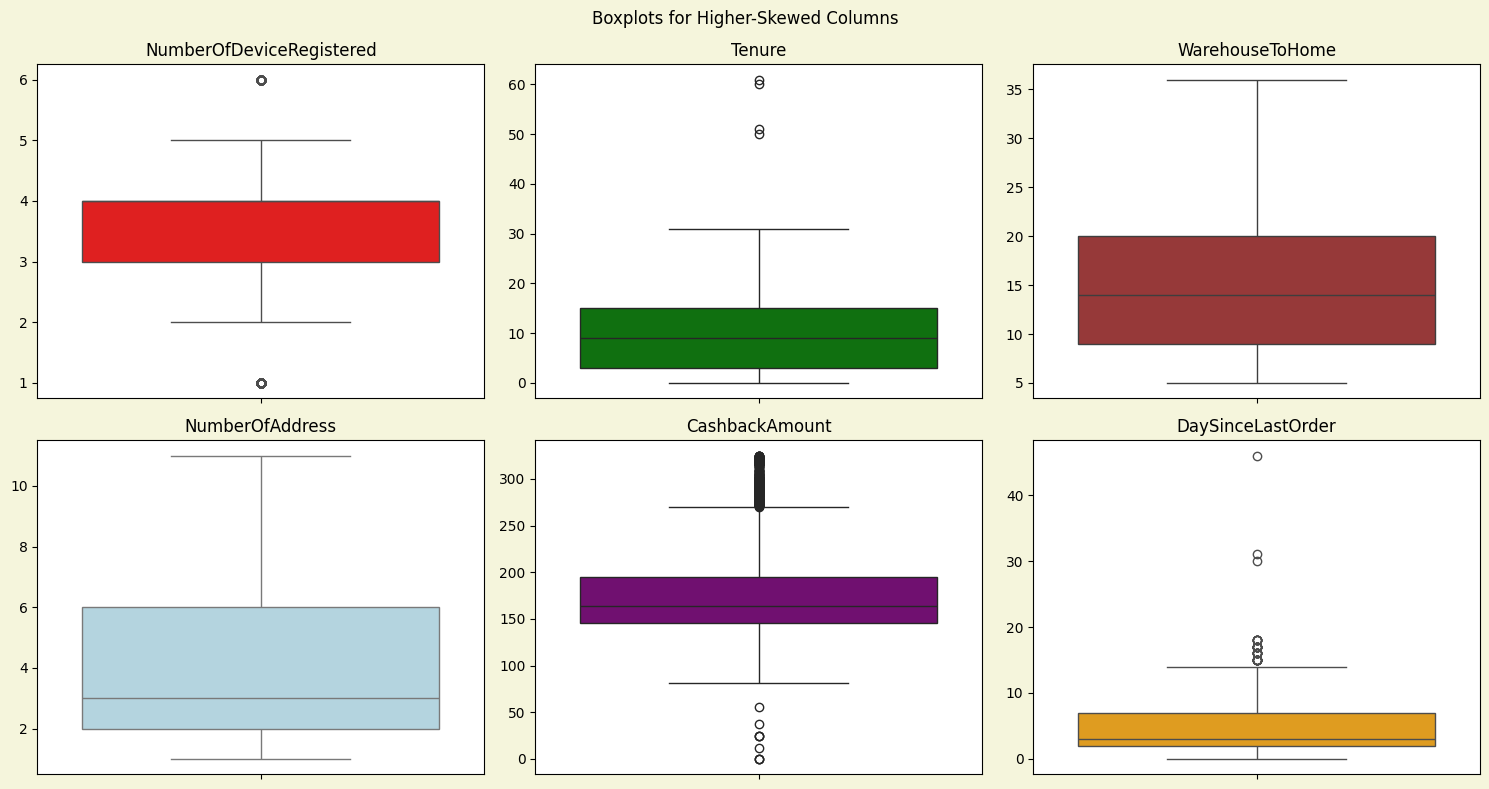

In [ ]:
IQR_cols = ['NumberOfDeviceRegistered', 'Tenure', 'WarehouseToHome', 'NumberOfAddress', 'CashbackAmount', 'DaySinceLastOrder']
fig, axes = plt.subplots(2, 3, figsize = (15, 8), facecolor = 'beige')
axes = axes.flatten() # is a method used to convert a multi-dimensional array of subplots into a one-dimensional (1D) array
colors, c = ['red', 'green', 'brown', 'lightblue', 'purple', 'orange'], 0

for ax, col in zip(axes, IQR_cols): # zip() takes the first item from each list and pairs them
    subset = df[col]
    sns.boxplot(subset, ax = ax, color = colors[c])
    ax.set_ylabel("")
    ax.set_title(col)
    c += 1

plt.suptitle('Boxplots for Higher-Skewed Columns')
plt.tight_layout()
plt.savefig('../figures/boxplot_higher_skewed.png', dpi=300, bbox_inches='tight')
plt.show()


#### Understanding the Boxplot Graphic

A boxplot is a standardized way of displaying the distribution of data based on a five-number summary. 
* **Minimum (Lower Whisker)**: The lowest data point excluding outliers. In a standard boxplot, this is calculated as $Q1 - 1.5 \times IQR$.
* **Q1 (First Quartile / 25th Percentile)**: The bottom edge of the box. 25% of the data falls below this value.
* **Median (Q2 / 50th Percentile)**: The line inside the box. It represents the middle value of the dataset.
* **Q3 (Third Quartile / 75th Percentile)**: The top edge of the box. 75% of the data falls below this value.
* **Maximum (Upper Whisker)**: The highest data point excluding outliers. Calculated as $Q3 + 1.5 \times IQR$.
* **IQR (Interquartile Range)**: The height of the box ($Q3 - Q1$). It represents the middle 50% of the data.
* **Outliers**: The individual dots or circles beyond the whiskers. These are values that are significantly higher or lower than the rest of the data.


#### Summary of the Boxplots

* Has outliers: `NumberOfDeviceRegistered`, `Tenure`, `CashbackAmount` and `DaySinceLastOrder`
* Does not have outliers: `WarehouseToHome` and `NumberOfAddress`

In the next steps, we will investigate these outliers to decide whether to treat them (capping/transformation) or keep them as legitimate extreme behaviors.

#### **Outlier Treatment**

##### **NumberOfDeviceRegistered Column**

In [ ]:
# outlier_columns = ["NumberOfDeviceRegistered", "Tenure", "CashbackAmount", "DaySinceLastOrder"]

min_value, max_value = df['NumberOfDeviceRegistered'].min(), df['NumberOfDeviceRegistered'].max()
Q1, Q2, Q3 = df["NumberOfDeviceRegistered"].quantile(0.25), df['NumberOfDeviceRegistered'].median(), df["NumberOfDeviceRegistered"].quantile(0.75)
IQR = Q3 - Q1
lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
print('\n===== NumberOfDeviceRegistered =====\n')
print(f"Minimum value = {min_value}\nlower_limit = {lower_limit}\nQ1 = {Q1}\nMedian (Q2)= {Q2}\nQ3 = {Q3}\nupper_limit = {upper_limit}\nMaximum value = {max_value}")

df['NumberOfDeviceRegistered'][(df["NumberOfDeviceRegistered"] > upper_limit) | (df["NumberOfDeviceRegistered"] < lower_limit)].value_counts()


===== NumberOfDeviceRegistered =====

Minimum value = 1
lower_limit = 1.5
Q1 = 3.0
Median (Q2)= 4.0
Q3 = 4.0
upper_limit = 5.5
Maximum value = 6


NumberOfDeviceRegistered
1    164
6    107
Name: count, dtype: int64

<u>**Observations**</u>

* In this case, the difference between the actual extremes and the IQR limits is only 0.5. This discrepancy is so subtle that elimination (Trimming) is unnecessary. 

* While **Capping** is often a preferred solution, it would result in non-integer values (like 1.5 or 5.5), which would be illogical for a count-based feature like registered devices.

* Therefore, **Retention** is the most adequate solution here. Registering 1 or 6 devices is perfectly domain-plausible behavior. Specifically, having 1 device is often the baseline for any customer, so it should not be treated as an anomaly regardless of the statistical limits.

##### **Tenure Column**

In [ ]:
min_value, max_value = df['Tenure'].min(), df['Tenure'].max()
Q1, Q2, Q3 = df["Tenure"].quantile(0.25), df['Tenure'].median(), df["Tenure"].quantile(0.75)
IQR = Q3 - Q1
lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
print('\n===== Tenure =====\n')
print(f"Minimum value = {min_value}\nlower_limit = {lower_limit}\nQ1 = {Q1}\nMedian (Q2) = {Q2}\nQ3 = {Q3}\nupper_limit = {upper_limit}\nMaximum value = {max_value}")

outliers = df['Tenure'][(df["Tenure"] > upper_limit) | (df["Tenure"] < lower_limit)].value_counts().sort_index()
outliers


===== Tenure =====

Minimum value = 0
lower_limit = -15.0
Q1 = 3.0
Median (Q2) = 9.0
Q3 = 15.0
upper_limit = 33.0
Maximum value = 61


Tenure
50    1
51    1
60    1
61    1
Name: count, dtype: int64

In [ ]:
print(f"Number of unique Tenure values: {df['Tenure'].value_counts().count()}") # df['Tenure'].nunique()
print(f"Percentage of the outliers per total no. of Tenure: {(outliers.count()/df['Tenure'].value_counts().count()):.2%}")

Number of unique Tenure values: 36
Percentage of the outliers per total no. of Tenure: 11.11%


In [ ]:
df['Tenure'].value_counts().sort_values()

Tenure
50      1
61      1
60      1
51      1
31     32
29     33
26     40
25     40
27     43
28     44
30     46
22     50
24     51
21     54
23     59
17     79
18     79
20     80
16    102
15    103
19    111
2     117
13    121
12    126
14    128
6     134
3     136
11    136
5     145
4     151
7     151
10    155
8     192
0     347
9     359
1     489
Name: count, dtype: int64

In [ ]:
print(f"{outliers.count() / df.shape[0]:.1%}") # 4 out of 3937 records

0.1%


<u>**Observations**</u>

* **Data Loss Minimization:** We identified that these extreme outliers represent only 0.1% of the total dataset (4 out of 3,937 records).

* **Statistical Stability:** While these values (reaching 4-5 years) might be valid, their extreme distance from the distribution mass significantly stretches the scale.
*(Assumed months based on distribution. However, in a real business scenario, I would verify this with the Data Engineering/Product team.)*

* **Decision:** Given the negligible impact on dataset size, we have opted for **Trimming** (Removal) to ensure a more stable and readable distribution without losing significant information.

In [ ]:
rows_before = len(df)
df = df[df['Tenure'] <= 31]
print(f"Removed {rows_before - len(df)} rows. Remaining data: {len(df)} rows.")

Removed 4 rows. Remaining data: 3933 rows.


##### **CashbackAmount Column**

In [ ]:
min_value, max_value = df['CashbackAmount'].min(), df['CashbackAmount'].max()
Q1, Q2, Q3 = df["CashbackAmount"].quantile(0.25), df['CashbackAmount'].median(), df["CashbackAmount"].quantile(0.75)
IQR = Q3 - Q1
lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
print('\n===== CashbackAmount =====\n')
print(f"Minimum value = {min_value}\nlower_limit = {lower_limit}\nQ1 = {Q1}\nMedian(Q2) = {Q2}\nQ3 = {Q3}\nupper_limit = {upper_limit}\nMaximum value = {max_value}")

outliers = df['CashbackAmount'][(df["CashbackAmount"] > upper_limit) | (df["CashbackAmount"] < lower_limit)].value_counts().sort_index()
outliers


===== CashbackAmount =====

Minimum value = 0.0
lower_limit = 71.27499999999999
Q1 = 145.66
Median(Q2) = 163.34
Q3 = 195.25
upper_limit = 269.635
Maximum value = 324.99


CashbackAmount
0.00      3
12.00     1
25.00     3
37.00     1
56.00     1
         ..
323.59    1
324.26    1
324.43    1
324.73    2
324.99    2
Name: count, Length: 205, dtype: int64

In [ ]:
print(f"Number of unique CashbackAmount values: {df['CashbackAmount'].nunique()}") 
print(f"No. of outliers: {outliers.count()}")
print(f"Percentage of the outliers per total no. of CashbackAmount: {(outliers.count()/df['CashbackAmount'].value_counts().count()):.2%}")

Number of unique CashbackAmount values: 2333
No. of outliers: 205
Percentage of the outliers per total no. of CashbackAmount: 8.79%


In [ ]:
df.CashbackAmount.value_counts().sort_index()

CashbackAmount
0.00      3
12.00     1
25.00     3
37.00     1
56.00     1
         ..
323.59    1
324.26    1
324.43    1
324.73    2
324.99    2
Name: count, Length: 2333, dtype: int64

<u>**Observations**</u>

* **Significant Outlier Volume:** The outliers represent 8.79% of the unique values (and 205 records in total). **Trimming** this amount of data would lead to significant information loss.

* **High-Value Customer Behavior:** These records likely represent high-spending or premium customers who receive more cashback.

* **Decision:** **Capping** (Winsorization). We will cap the values at the **upper_limit** (269.63). This treats these records as "Maximum Reward" cases without allowing the extreme 300+ values. The lower values (from 0 to 71.27), however, are considered plausible and realistic for standard customers, so they will remain unaltered.

In [ ]:
df['CashbackAmount'].clip(upper = upper_limit, inplace = True) # limiting

# checking again the upper outliers
df['CashbackAmount'][df['CashbackAmount'] >= upper_limit].value_counts()


CashbackAmount
269.635    304
Name: count, dtype: int64

In [ ]:
print(f"New maximum value: {df['CashbackAmount'].max()}")
print(f"Values greater than the upper limit: {len(df[df['CashbackAmount'] > upper_limit])}")
print(f"Values (greater than or) equal to the upper limit: {len(df[df['CashbackAmount'] >= upper_limit])}")

New maximum value: 269.635
Values greater than the upper limit: 0
Values (greater than or) equal to the upper limit: 304


##### **DaySinceLastOrder Column**

In [ ]:
min_value, max_value = df['DaySinceLastOrder'].min(), df['DaySinceLastOrder'].max()
Q1, Q2, Q3 = df["DaySinceLastOrder"].quantile(0.25), df['DaySinceLastOrder'].median(), df["DaySinceLastOrder"].quantile(0.75)
IQR = Q3 - Q1
lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
print('\n===== DaySinceLastOrder =====\n')
print(f"Minimum value = {min_value}\nlower_limit = {lower_limit}\nQ1 = {Q1}\nMedian(Q2) = {Q2}\nQ3 = {Q3}\nupper_limit = {upper_limit}\nMaximum value = {max_value}")

outliers = df['DaySinceLastOrder'][(df["DaySinceLastOrder"] > upper_limit) | (df["DaySinceLastOrder"] < lower_limit)].value_counts().sort_index()
outliers


===== DaySinceLastOrder =====

Minimum value = 0
lower_limit = -5.5
Q1 = 2.0
Median(Q2) = 3.0
Q3 = 7.0
upper_limit = 14.5
Maximum value = 46


DaySinceLastOrder
15    13
16     8
17    12
18     7
30     1
31     1
46     1
Name: count, dtype: int64

In [ ]:
print(f"Number of unique DaySinceLastOrder values: {df['DaySinceLastOrder'].nunique()}") 
print(f"No. of outliers: {outliers.count()}")
print(f"Percentage of the outliers per total no. of DaySinceLastOrder: {(outliers.count()/df['DaySinceLastOrder'].value_counts().count()):.2%}")

Number of unique DaySinceLastOrder values: 22
No. of outliers: 7
Percentage of the outliers per total no. of DaySinceLastOrder: 31.82%


In [ ]:
print(f"Total no. of outliers: {outliers.sum()}")
print(f"Percantage of the outliers below 20 Days: {(outliers[outliers.index <= 20].sum() / outliers.sum()):.2%}")

Total no. of outliers: 43
Percantage of the outliers below 20 Days: 93.02%


<u>**Observations**</u>
* Up to Day 20 (inclusive) we will consider the customers as active members. Above this number their status is going to change to inactive.
* Considering the fact that 93% of the outliers (so far) are actually yet active members - the 20-days time limit has not expired - they will be treated as part of the normal distribution. Thus, the ones that need alteration are the 7%, with a frequency of one. These 3 elements are going to be removed permanently (for 30, 31 and 46 days inactivity).

In [ ]:
rows_before = len(df)
df.drop(df[df['DaySinceLastOrder'] > 20].index, inplace = True)
print(f"Removed {rows_before - len(df)} rows. Remaining data: {len(df)} rows.")

Removed 3 rows. Remaining data: 3930 rows.


**Summary**: The Numerical-Type columns have been reviewed. No other intervention needed.

##### Function for calculating the **IQR values** (optional)

In [ ]:
def IQR_values(df, col):
    min_value, max_value = df[col].min(), df[col].max()
    Q1, Q2, Q3 = df[col].quantile(0.25), df[col].median(), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit, upper_limit = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    
    print(f"\n===== {col} =====\n")
    print(f"Minimum value = {min_value}\nlower_limit = {lower_limit}\nQ1 = {Q1}\nMedian(Q2) = {Q2}\nQ3 = {Q3}\nupper_limit = {upper_limit}\nMaximum value = {max_value}\n")

    outliers = df[col][(df[col] > upper_limit) | (df[col] < lower_limit)].value_counts().sort_index()
    print(outliers)

In [ ]:
outlier_columns = ["NumberOfDeviceRegistered", "Tenure", "CashbackAmount", "DaySinceLastOrder"]
for col in outlier_columns:
    IQR_values(df, col)


===== NumberOfDeviceRegistered =====

Minimum value = 1
lower_limit = 1.5
Q1 = 3.0
Median(Q2) = 4.0
Q3 = 4.0
upper_limit = 5.5
Maximum value = 6

NumberOfDeviceRegistered
1    163
6    107
Name: count, dtype: int64

===== Tenure =====

Minimum value = 0
lower_limit = -15.0
Q1 = 3.0
Median(Q2) = 9.0
Q3 = 15.0
upper_limit = 33.0
Maximum value = 31

Series([], Name: count, dtype: int64)

===== CashbackAmount =====

Minimum value = 0.0
lower_limit = 71.29999999999997
Q1 = 145.67
Median(Q2) = 163.34
Q3 = 195.25
upper_limit = 269.62
Maximum value = 269.635

CashbackAmount
0.000        3
12.000       1
25.000       3
37.000       1
56.000       1
269.635    304
Name: count, dtype: int64

===== DaySinceLastOrder =====

Minimum value = 0
lower_limit = -5.5
Q1 = 2.0
Median(Q2) = 3.0
Q3 = 7.0
upper_limit = 14.5
Maximum value = 18

DaySinceLastOrder
15    13
16     8
17    12
18     7
Name: count, dtype: int64


**Observation on Automation:** While this automated function simplifies the outlier detection process, I chose to perform the initial analysis manually for each column. This allowed for a more granular review and ensured that treatment decisions (**Trimming** vs. **Capping**) were guided by specific business logic.

**Note**: To function correctly as a diagnostic tool, this code block should be executed before any data cleaning. Running it on already treated data will result in empty outlier sets or inaccurate statistical summaries.

---
### **Final Sanity Check (Numerical Cleaning)**


After performing **trimming** (on `Tenure` and `DaySinceLastOrder`) and **capping** (on `CashbackAmount`), it is essential to re-synchronize the dataset. 

1. **Index Resetting**: Removing rows creates gaps in the DataFrame's index. Resetting ensures a continuous integer sequence to prevent errors in downstream processing.
2. **Data Retention Audit**: We verify the final row count to ensure that our total data loss remains within acceptable limits (typically < 1-2%).

In [ ]:
# Resetting the index after dropping rows
rows_before_all = 3937 # The initial count before numerical cleaning
df.reset_index(drop=True, inplace=True)

print("===== Final Sanity Check =====")
print(f"Initial row count: {rows_before_all}")
print(f"Final row count:   {df.shape[0]}")
print(f"Total rows lost:   {rows_before_all - df.shape[0]}")
print(f"Data retention:    {(df.shape[0] / rows_before_all):.2%}")

===== Final Sanity Check =====
Initial row count: 3937
Final row count:   3930
Total rows lost:   7
Data retention:    99.82%


---

## **Categorical Data**

**Categorical values** represent types of data which may be divided into groups or labels rather than expressed as measurable numbers. They describe qualitative characteristics and are used to classify information into distinct categories such as gender, marital status, or product type.

<u>**Key Characteristics:**</u>
* **Qualitative nature:** They answer the "What kind?" or "Which group?" questions instead of "How much?".

* **Limited values:** They usually consist of a fixed and finite number of possible values (e.g., "Yes" or "No").

* **Frequency-based analysis:** Instead of mean or sum, we analyze them using mode (most frequent value), counts, or percentages (proportions).

The **mode()** function is used to identify the most frequently occurring value within a dataset, making it the primary measure of central tendency for categorical variables where calculating a mean or median is not possible.

### **Categorical Features Distribution** - measuring the number of unique values in a column.

In this section, we examine the distribution of our categorical variables. Instead of simply looking at the **Mode** (the single most frequent element), these visualizations allow us to understand the complete landscape of each category, including the **Relative Frequency** of every label.

[2049 1307  574]


C:\Users\Erwin\AppData\Local\Temp\ipykernel_22800\1548787606.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df[col], ax = ax, palette = 'viridis', order = order)
C:\Users\Erwin\AppData\Local\Temp\ipykernel_22800\1548787606.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df[col], ax = ax, palette = 'viridis', order = order)
C:\Users\Erwin\AppData\Local\Temp\ipykernel_22800\1548787606.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = df[col], ax = ax, palette = 'viridis', order = order)
C:\Users\Erwin\AppData\Lo

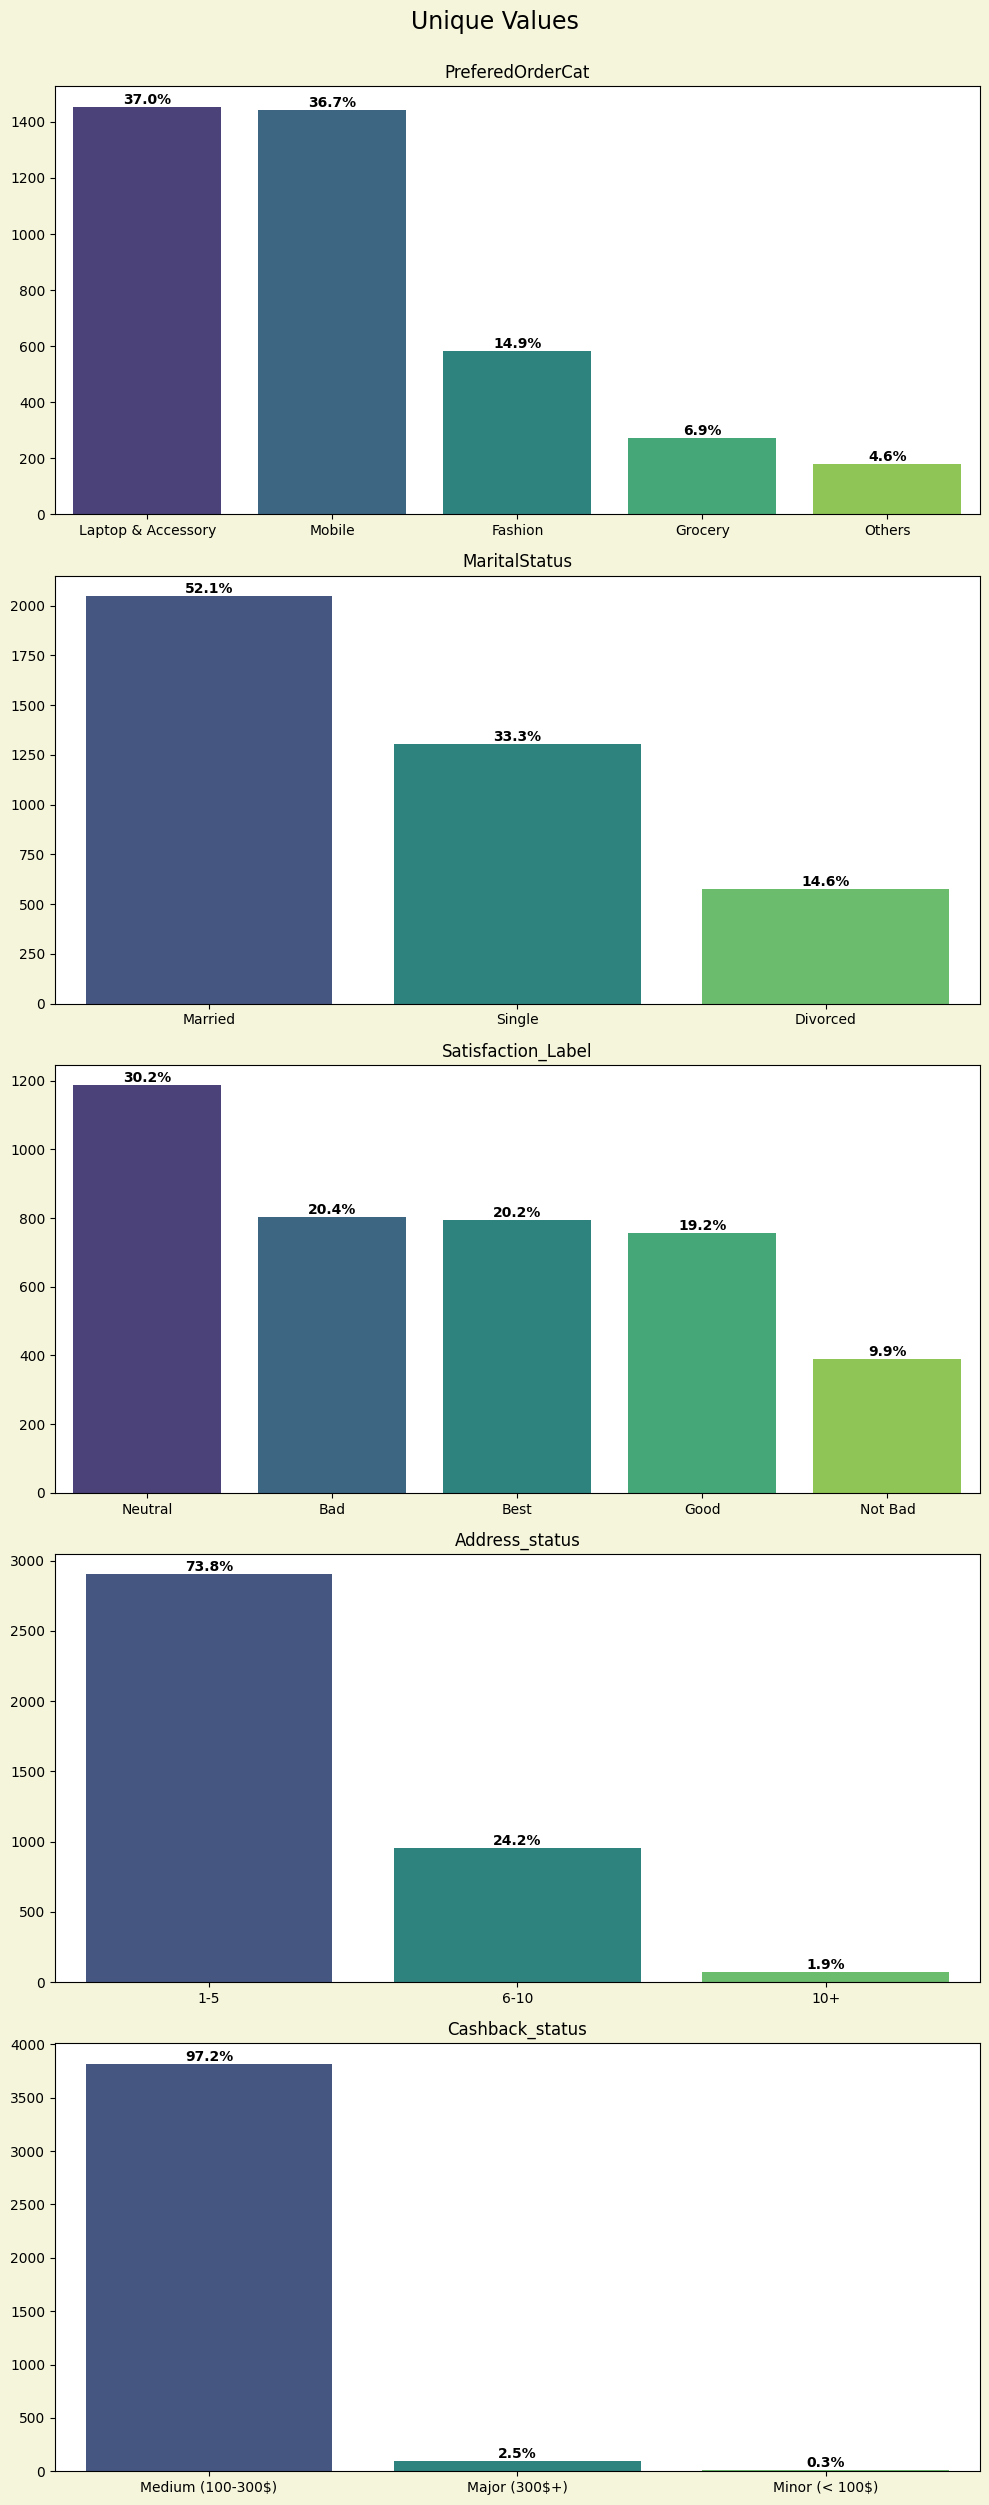

In [ ]:
fig, axes = plt.subplots(5, 1, figsize = (10, 25), facecolor = 'beige')
axes = axes.flatten()
perc = df['MaritalStatus'].value_counts().values
print(perc)
for col, ax in zip(cat_cols, axes):
#    ax.set_facecolor('beige')
    order = df[col].value_counts().index
    perc = df[col].value_counts().values * 100 / df[col].value_counts().values.sum()
    counts = df[col].value_counts().values
    sns.countplot(x = df[col], ax = ax, palette = 'viridis', order = order)
    for i, p in enumerate(perc):
        ax.text(x = i, 
                y = counts[i], 
                s = f"{p:.1f}%",                      
                ha = 'center', 
                va = 'bottom',
                fontsize = 10, 
                fontweight = 'bold')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(col)

plt.suptitle('Unique Values', fontsize = 17, y = 1)
plt.tight_layout()
plt.savefig(f'../figures/unique_percentage.png', dpi=300, bbox_inches='tight')
plt.show()

<u>**Key Observations:**</u>
* **Comprehensive Insights:** By displaying percentages above each bar, we can immediately identify not only the **Most Common** (dominant) labels but also the **Least Common** (Rare Labels). This provides a more granular understanding than a basic mode calculation.

* **Dominant Categories:** 
    * `Cashback_status`: Shows an extreme concentration, with **Medium (100-300$)** accounting for **97.2%** of the data. This variable is nearly constant, which is a crucial observation for future modeling.

    * `Address_status`: The **1-5 years** category is dominant (**73.8%**), suggesting a relatively young customer base in terms of platform usage or address history.

* **Balanced vs. Skewed Distributions:**

    * `MaritalStatus`: While **Married** is the most common (**52.1%**), there is a healthy representation of **Single** (**33.3%**) and Divorced (**14.6%**) customers.

    * `Satisfaction_Label`: This feature is well-distributed, with **Neutral** being the most frequent (**30.2%**), but even the rarest category (**Not Bad**) holds a significant **9.9%** share.

* **Product Preferences:** **Laptop & Accessory** (**37.0%**) and **Mobile** (**36.7%**) are the primary drivers of orders, together making up nearly **74%** of the preferred categories.

**Strategic Note:** Identifying **Rare Labels** (like **Minor (< 100$)** in `Cashback_status` or **10+** in `Address_status`) is vital. If a category's frequency is too low (e.g., < 5%), we may need to consider grouping it during the data preparation phase to avoid overfitting.

### **Business Summary & Strategic Findings**

Based on the distribution of categorical features, we can define the **Typical Customer Profile**.

#### **1. Typical Customer Profile**

* **Marital Status**: The majority of customers are **Married** (**52.1%**), with a significant segment being **Single** (**33.3%**).

* **Platform Tenure**: Most customers are relatively young in terms of platform history, with **73.8%** having an **Address Status** of **1-5 years**.

* **Product Preference**: The core business is driven by **Laptop & Accessory** (**37%**) and **Mobile** (**36.7%**), accounting for nearly **74%** of all preferred order categories.

#### **2. Low Variance Alert (Feature Selection)**


`Cashback_status`: This column shows an extreme concentration, where **97.2%** of customers fall into the "**Medium**" category.

Due to the near-zero variance, this feature provides almost no discriminatory power to distinguish between staying and churning customers. It will be excluded from further correlation analysis to avoid noise, because it won't help us distinguish between customers who churn and those who stay. We will drop this column to simplify our dataset and focus on more impactful features.

In [ ]:
# Dropping the column due to near-zero variance
df.drop(columns=['Cashback_status'], inplace=True)

# Update our categorical columns list
cat_cols.remove('Cashback_status')

print("Column 'Cashback_status' has been removed. Remaining categorical features:", cat_cols)

Column 'Cashback_status' has been removed. Remaining categorical features: ['PreferedOrderCat', 'MaritalStatus', 'Satisfaction_Label', 'Address_status']


#### **3. Redundancy & Feature Choice**



`Satisfaction_Label` vs. `SatisfactionScore`: These two columns represent the same information in different formats.

**Decision**: For the upcoming business analysis and churn correlation, we will prioritize the `Satisfaction_Label` as it offers better readability for stakeholder reporting. The numerical score will be retained only for specific statistical calculations if needed.

In [ ]:
# print(df[['SatisfactionScore', 'Satisfaction_Label']])
df.drop(columns = ['SatisfactionScore'], inplace = True)
df.rename(columns={'Satisfaction_Label': 'Satisfaction'}, inplace=True)
# df.columns.unique()

## Bivariate Analysis & Business Optimization

### Driving Business Insights
In this section, we move beyond individual variables to investigate the relationships between customer characteristics and our primary target, `Churn`. By examining key drivers such as **Tenure**, **Logistics (Distance)**, and **Customer Satisfaction**, we aim to identify the specific pain points where the company loses revenue and pinpoint strategic opportunities for customer retention. This analysis will distinguish between early-stage friction and long-term loyalty issues, providing a data-driven foundation for targeted business interventions.

#### **1. Tenure vs. Churn**



The relationship between membership length (`Tenure`) and `Churn` is the most critical metric. Identifying *when* customers leave reveals exactly where the strategy is failing:

* **Early-Stage Churn (New Members)**: If the "newcomers" are leaving quickly, the issue lies in the marketing alignment or the onboarding process. We are either attracting the wrong audience or failing to demonstrate value immediately.

* **Late-Stage Churn (Long-term Members)**: If the "veterans" are leaving, the problem is the loyalty program or product stagnation. We are not giving long-term users a reason to stay, or the competition has caught up.

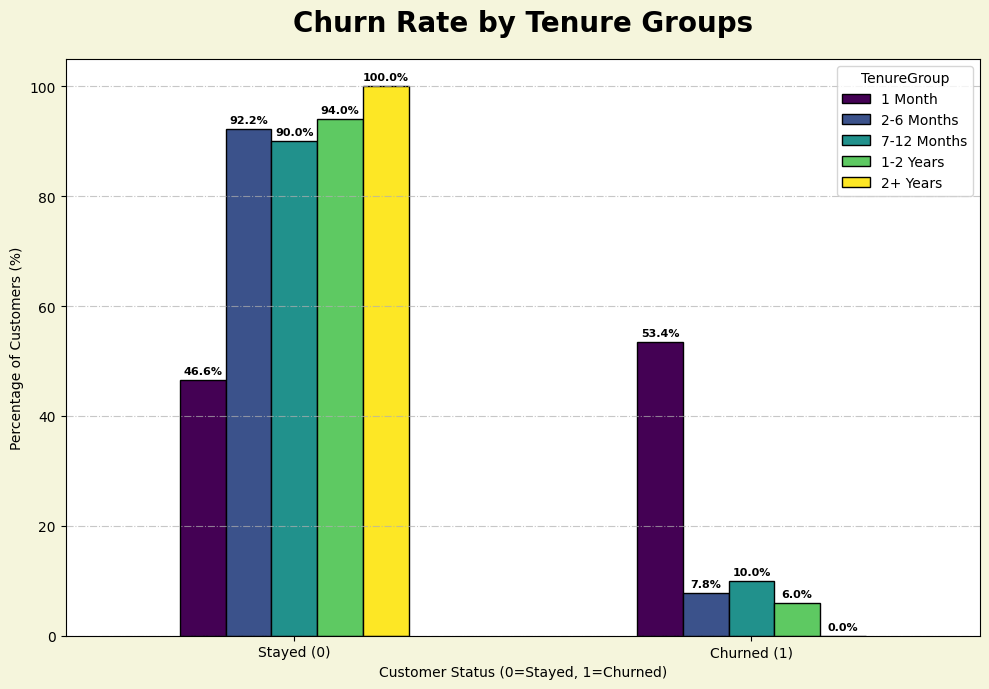

In [ ]:
import numpy as np

# for a better understading we are going to divide the Tenure field in buckets in order
# to visualize whether newcomers or veterans are more likely to leave.

df['TenureGroup'] = pd.cut(df.Tenure, bins = [0, 1, 6, 12, 24, np.inf], labels = ['1 Month', '2-6 Months', '7-12 Months', '1-2 Years', '2+ Years'], include_lowest = True)
tenure_churn = pd.crosstab(df['Churn'], df['TenureGroup'], normalize='columns') * 100
# normalize = 'columns' (/index/all) calculating percentages relative to each column (tenure group)

fig, ax = plt.subplots(figsize = (10, 7), facecolor = 'beige')
# ax.set_facecolor('beige')
tenure_churn.plot(kind = 'bar', ax = ax, colormap = 'viridis', edgecolor = 'black')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8, fontweight='bold')

plt.title('Churn Rate by Tenure Groups', fontsize = 20, pad = 20, fontweight = 'bold')
plt.ylabel('Percentage of Customers (%)')
plt.xlabel('Customer Status (0=Stayed, 1=Churned)')
plt.xticks(range(len(tenure_churn.index)), ['Stayed (0)', 'Churned (1)'], rotation = 0)
plt.grid(axis = 'y', linestyle = '-.', alpha = .7)
plt.tight_layout()
plt.savefig('../figures/churn_tenure.png', dpi=300, bbox_inches='tight')
plt.show()

##### <u>**Key Conclusion:</u> The "First-Month Crisis"**
The visualization clearly identifies a critical friction point in the customer journey: **onboarding and early engagement**.

* **Critical Risk Group**: There is an alarming **53.4%** churn rate among customers with only **1 month of tenure**. Over half of the newly acquired users leave the platform almost immediately after their first interaction.

* **Loyalty Correlation**: As tenure increases, the probability of churn drops significantly. By the time a customer reaches the **2+ Years** mark, the churn rate effectively hits **0%**, indicating that long-term users are highly stable and loyal.

* **Business Opportunity**: The company’s retention efforts are currently misaligned. Instead of broad loyalty programs for veterans, the focus must shift to an **Aggressive Onboarding Strategy**.

**Actionable Insight**: Improving the first-month experience by just **10%** (reducing churn from 53.4% to 43.4% in that group) would result in a massive increase in Customer Lifetime Value (CLV), as retained users show high long-term stability once they pass the 6-month threshold.

#### **2. Warehouse Distance vs. Churn Analysis**




The correlation between `WarehouseToHome` (distance from the warehouse to the customer) and Churn measures the **logistics efficiency**. This analysis identifies whether there is a "critical distance" beyond which shipping times or costs become a dealbreaker for the customer.

* **Logistics Friction**: If churn spikes significantly as distance increases, it suggests that the delivery window or shipping fees are no longer competitive for those regions.

* **The "Critical Threshold"**: Identifying the exact distance (e.g., 15+ km) where retention drops allows us to optimize the delivery zones, adjust pricing tiers, or consider localized fulfillment centers.

To understand how logistics affect customer retention, we employed two distinct visualization methods. While both use the `WarehouseToHome` variable, they serve different analytical purposes.

<u>**Method 1: Categorical Binning (Bar Chart)**</u>
* **Why we use it**: Real-world logistics often operate in "zones." By grouping distances into categories like **Local**, **Regional**, or **Extreme**, we can identify clear business thresholds.

* **Interpretation**: This chart provides an immediate "Churn Rate" for each zone. For instance, seeing that churn jumps from **13.9%** (Local) to **20.8%** (Distal) tells a manager exactly where the delivery service starts losing its competitive edge.

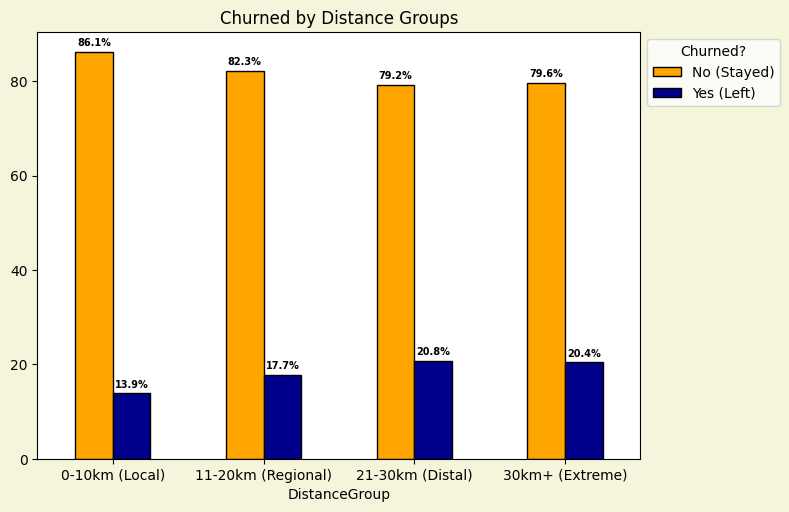

In [ ]:
df['DistanceGroup'] = pd.cut(df.WarehouseToHome, 
                             bins = [0, 10, 20, 30, np.inf], 
                             labels = ['0-10km (Local)', '11-20km (Regional)', '21-30km (Distal)', '30km+ (Extreme)'])

warehouse_churn = pd.crosstab(df.DistanceGroup, df.Churn, normalize = 'index') * 100
fig, ax = plt.subplots(figsize = (8, 5), facecolor = 'beige')
warehouse_churn.plot(kind = 'bar', ax = ax, color = ['orange', 'darkblue'], edgecolor = 'black')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding = 3, fontsize = 7, fontweight = 'bold')
plt.legend(title = 'Churned?', labels = ['No (Stayed)', 'Yes (Left)'], bbox_to_anchor = (1, 1))
plt.xticks(rotation = 0)
plt.tight_layout()
plt.title("Churned by Distance Groups")
plt.savefig('../figures/churn_distance.png', dpi=300, bbox_inches='tight')
plt.show()    



<u>**Method 2: Linear Regression Analysis (Regplot)**</u>
* **Why we use it**: It prevents us from losing the "fine details" that binning might hide. It shows the raw relationship between every single kilometer and the likelihood of a customer leaving.

* **How to interpret this graph step-by-step:**

    1. **Orange Dots:** Each dot represents a specific distance (e.g., exactly 12 km). Its height on the Y-axis represents the average churn percentage for customers at that exact distance.

    2. **The Dark Blue Line:** This is the "Trend Line." It smooths out the "noise" of individual data points to show the overall direction. Because it slopes **upward**, it scientifically confirms that as distance increases, churn probability also increases.

    3. **The Light Blue Shaded Area:** This represents the **Confidence Interval**. A narrow band means we have plenty of data and the trend is reliable. A wider band (often seen at the far right) indicates that we have fewer data points for those distances, making the prediction less certain.

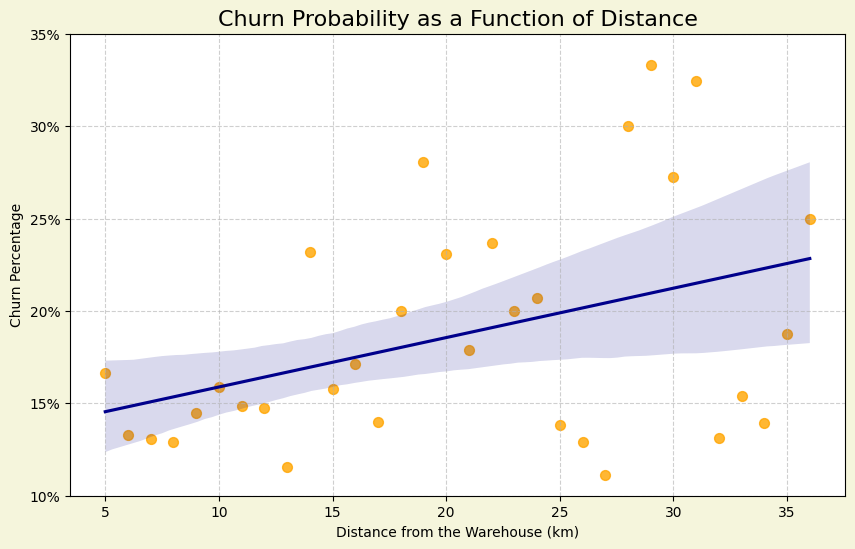

In [ ]:
import seaborn as sns

distance_stats = df.groupby('WarehouseToHome')['Churn'].mean().reset_index()

plt.figure(figsize = (10, 6), facecolor='beige')
sns.regplot(data = distance_stats, x = 'WarehouseToHome', y = 'Churn', 
            color = 'darkblue', scatter_kws = {'s':50, 'color':'orange'})

plt.title('Churn Probability as a Function of Distance', fontsize=16)
plt.ylabel('Churn Percentage')
plt.yticks([0.1, 0.15, 0.20, 0.25, 0.30, 0.35], ['10%', '15%', '20%', '25%', '30%', '35%'])
plt.xlabel('Distance from the Warehouse (km)')
plt.grid(True, linestyle='--', alpha = 0.6)
plt.savefig('../figures/churn_distance_regplot.png', dpi=300, bbox_inches='tight')
plt.show()

##### <u>**Conclusion & Business Insight**</u>
By combining these two methods, we can move from "assumptions" to "scientific facts":

1. **The Logistic Friction Point:** Our data confirms a clear upward trend. Customers living within **10 km** are significantly more loyal. Once the distance exceeds **11–15 km**, we hit a "friction point" where churn rates stabilize at a much higher level (roughly **20%**).

2. **The Reliability Gap:** The **Regplot** validates our initial observation regarding data density. As we move toward the "Extreme" distances (30 km+), the orange dots become more scattered and the light blue shaded area widens. This proves that **we lack sufficient data for very distant locations**, leading to those "highly volatile" or erratic fluctuations at the end of the graph.

3. **Strategic Action:** Based on this evidence, the company should either optimize delivery speeds for the **11–25 km** range to lower that **20%** churn or focus marketing efforts on the **"Local" (0–10 km)** zone where the business model is currently most successful.

#### **3. Complaint vs. Satisfaction Correlation**




This analysis allows us to identify the **"Silent Churners"**: customers who leave despite never filing a formal complaint. These are the most dangerous segments because they provide no direct feedback before exiting.

* **The "Silent Churner" Segment:** By cross-referencing high dissatisfaction scores with a lack of formal complaints, we can pinpoint users who felt that voicing their issues wasn't worth the effort.

* **Gap Analysis:** This reveals flaws in your feedback loop. If a large portion of dissatisfied customers don't complain, your complaint-filing process might be too difficult, or customers may feel their feedback won't lead to change.


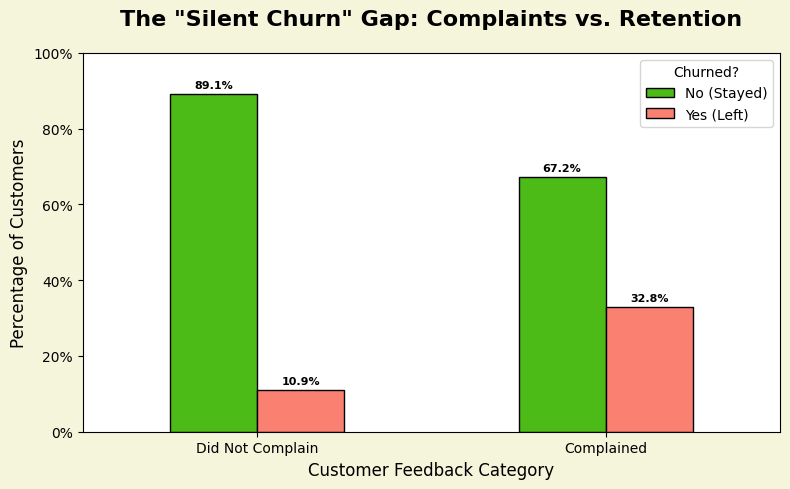

In [ ]:
complaint_churn = pd.crosstab(df.Complain, df.Churn, normalize = 'index') * 100
fig, ax = plt.subplots(figsize = (8, 5), facecolor = 'beige')
complaint_churn.plot(kind = 'bar', ax = ax, color = ['#4cbb17', 'salmon'], edgecolor = 'black')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding = 3, fontsize=8, fontweight='bold')

plt.title('The "Silent Churn" Gap: Complaints vs. Retention', fontsize=16, pad=20, weight = 'bold')
plt.xlabel('Customer Feedback Category', fontsize=12)
plt.ylabel('Percentage of Customers', fontsize=12)
plt.xticks([0, 1], ['Did Not Complain', 'Complained'], rotation = 0)
plt.yticks([0, 20, 40, 60, 80, 100], ['0%', '20%', '40%', '60%', '80%', '100%'])
plt.legend(title = 'Churned?', labels = ['No (Stayed)', 'Yes (Left)'])
plt.tight_layout()
plt.savefig('../figures/churn_complain.png', dpi=300, bbox_inches='tight')
plt.show()

<u>**Key Insights**</u>

* **The "Vocal" Churn Spike:** Among customers who filed a formal complaint, **32.8%** ended up leaving. This means nearly **one-third** of dissatisfied customers who speak up will churn, indicating that our current recovery strategies or complaint resolution processes are failing to win them back.

* **The Silent Majority:** Conversely, customers who **did not complain** show a much higher retention rate, with only **10.9%** churning. While this is a better figure, it still represents a "silent" loss that occurs without any prior warning or feedback.

* **Strategic Pivot:** The data clearly shows that a formal complaint is a **major red flag**. We are currently losing 1 in 3 complaining customers. The priority must shift to **Service Recovery** - fixing the issues of those who speak up before they walk out the door.


To validate the visual trends, we performed a precise count of the customer segments. This step is crucial to understand the volume of users affected by the "Vocal Churn" phenomenon versus the "Silent" baseline.

In [ ]:
# Number Of Customers Who Complained vs. Did Not Complain - Analysis
print(f"Total No. of customers: {df.shape[0]}")
print('=' * 50)
print(f"No. of customers who DID NOT complain: {df[df['Complain'] == 0].shape[0]} ({((df[df['Complain'] == 0].shape[0] * 100) / df.shape[0]):.1f}%)")
print(f"No. of customers who DID NOT complain & stayed {df[(df['Complain'] == 0) & (df['Churn'] == 0)].shape[0]} ({((df[(df['Complain'] == 0) & (df['Churn'] == 0)].shape[0] * 100) / df[df['Complain'] == 0].shape[0]):.1f}%)")
print(f"No. of customers who DID NOT complain & left {df[(df['Complain'] == 0) & (df['Churn'] == 1)].shape[0]} ({(((df[(df['Complain'] == 0) & (df['Churn'] == 1)].shape[0]) * 100) / df[df['Complain'] == 0].shape[0]):.1f}%)")
print('=' * 50)
print(f"No. of customers who complained: {df.Complain[df['Complain'] == 1].count()} ({((df.Complain[df['Complain'] == 1].count() * 100) / df.shape[0]):.1f}%)")
print(f"No. of customers who complained & stayed {df[(df['Complain'] == 1) & (df['Churn'] == 0)].shape[0]} ({(((df[(df['Complain'] == 1) & (df['Churn'] == 0)].shape[0]) * 100) / df.Complain[df['Complain'] == 1].count()):.1f}%)")
print(f"No. of customers who complained & left {df[(df['Complain'] == 1) & (df['Churn'] == 1)].shape[0]} ({(((df[(df['Complain'] == 1) & (df['Churn'] == 1)].shape[0]) * 100) / df.Complain[df['Complain'] == 1].count()):.1f}%)")

Total No. of customers: 3930
No. of customers who DID NOT complain: 2820 (71.8%)
No. of customers who DID NOT complain & stayed 2512 (89.1%)
No. of customers who DID NOT complain & left 308 (10.9%)
No. of customers who complained: 1110 (28.2%)
No. of customers who complained & stayed 746 (67.2%)
No. of customers who complained & left 364 (32.8%)


<u>**Statistical Summary: The "Rule of Thirds":**</u>

The quantitative data confirms a stark reality through a compounding effect we can call the **"One-Ninth Rule"**:

* **Complaint Frequency:** Only about **one-third** of our total customer base (1.110 out of 3.930, or approx. **28.2%**) actually voices a complaint. The vast majority remains silent.

* **Vocal Churn Probability:** Within that complaining group, again, roughly **one-third (32.8%)** ends up leaving.

* **The Compounded Impact:** When we combine these figures, we see that approximately **1/3 of 1/3 or 1/9 (roughly 11%)** of our entire customer base consists of individuals who both complain and churn.

**Strategic Recommendation:** Since this group represents a specific, high-risk subset, the company can afford to implement **high-touch, high-resource recovery interventions** (e.g., direct outreach, personalized discount codes) specifically for customers who file a complaint, as they are 3x more likely to churn than those who remain silent.

Now that we have established that **Complaining = High Risk** and identified the exact scale of this group, we need to understand the "why" behind these "1-in-9" customers. To prevent these red flags from occurring, we will perform a deep dive into the following:

* **Satisfaction Score Deep Dive:** We will analyze if the `SatisfactionScore` matches the complaint behavior. Are these customers consistently unhappy, or did a single bad experience trigger the exit?

* **Financial & Incentive Correlation:** We will examine the `CashbackAmount` and `OrderAmount` fields. This will help us determine if high-value customers are being compensated enough when issues arise.

* **Product Affinity:** Are certain categories (ex. Laptops vs. Accessories) more prone to high-churn complaints?

Most common Satisfaction value for those who did not complain: Neutral
Most common Satisfaction value for those who complained: Neutral
Most common Satisfaction value for those who churned (left): Neutral
No. of those who Complained & Churned & their Rating (Satisfaction) is 4-5: 164 (4.2% of total)


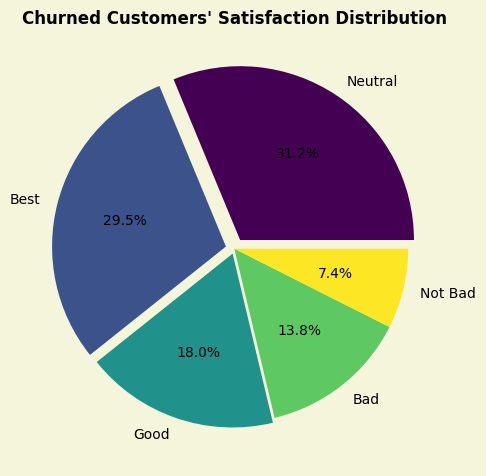

In [ ]:
print(f"Most common Satisfaction value for those who did not complain: {df['Satisfaction'][df['Complain'] == 0].mode()[0]}")
print(f"Most common Satisfaction value for those who complained: {df['Satisfaction'][df['Complain'] == 1].mode()[0]}")
print(f"Most common Satisfaction value for those who churned (left): {df['Satisfaction'][df.Churn == 1].mode()[0]}")
query = df.query('Churn == 1 and Complain == 1 and Satisfaction in ("Good", "Best")').shape[0]
print(f'No. of those who Complained & Churned & their Rating (Satisfaction) is 4-5: {query} ({query * 100 / df.shape[0]:.1f}% of total)')
fig = plt.figure(figsize = (5, 5), facecolor = 'beige')
df['Satisfaction'][df.Churn == 1].value_counts().plot(kind = 'pie', colormap = 'viridis', autopct = '%1.1f%%', explode = [.06, .05, .03, 0, 0])
plt.ylabel("")
plt.title("Churned Customers' Satisfaction Distribution", weight = 'bold')
plt.tight_layout()
plt.savefig('../figures/churn_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()


This analysis cross-references subjective customer feedback (Satisfaction Score) with actual behavior (Churn and Complaints) to identify the "Voice of the Customer" gap.

<u>**Key Insights:**</u>
* **The Neutral Danger Zone:** The most common satisfaction score across all segments - including those who stayed and those who churned - is **Neutral (3)**. This indicates that a significant portion of the customer base is "passive"; they are not necessarily unhappy, but they lack the loyalty to resist competitors' offers.

* **High-Satisfaction Churn:** Surprisingly, the top three ratings among churned customers are **Neutral (31.2%)**, **Best (29.5%)**, and **Good (18.0%)**. Combined, nearly **half (47.5%)** of the customers who left the platform rated their experience as 4 or 5 stars.

* **The "Silent" Exit of Happy Customers:** We identified **164 customers (4.2% of the total base)** who complained, rated the service as Good or Best, and still left. This suggests that for these individuals, the churn was likely not driven by long-term dissatisfaction, but by a specific unresolved incident or a superior offer elsewhere that outweighed their general satisfaction.

* **Lack of Negative Feedback:** The lowest ratings (Bad-1 and Not Bad-2) are the least frequent among churners. This is a critical finding: **Customers are not leaving because they hate the service; they are leaving because the service is not providing enough unique value to keep them from switching.**

In [ ]:
print(f"Median Amount of Cashback of Complaining & Churned people with High Rating {(df.CashbackAmount[(df.Complain == 1) & (df.Churn == 1) & ((df.Satisfaction == 'Good') | (df.Satisfaction == 'Best'))].median()):.2f}")
print(f"Median Amount of Cashback of Complaining & Stayed people with High Rating {(df.CashbackAmount[(df.Complain == 1) & (df.Churn == 0) & ((df.Satisfaction == 'Good') | (df.Satisfaction == 'Best'))].median()):.2f}")
print(f"Median Amount of Cashback of Complaining & Churned people with Low Rating {(df.CashbackAmount[(df.Complain == 1) & (df.Churn == 1) & ((df.Satisfaction == 'Not Bad') | (df.Satisfaction == 'Bad'))].median()):.2f}")
print(f"Median Amount of Cashback of Complaining & Stayed people with Low Rating {(df.CashbackAmount[(df.Complain == 1) & (df.Churn == 0) & ((df.Satisfaction == 'Not Bad') | (df.Satisfaction == 'Bad'))].median()):.2f}")
print('=' * 80)
print(f"Most preferred order category of Cashback of Complaining Churned people with High Rating: {df.PreferedOrderCat[(df.Complain == 1) & (df.Churn == 1) & ((df.Satisfaction == 'Good') | (df.Satisfaction == 'Best'))].mode()[0]} ({df.PreferedOrderCat[(df.Complain == 1) & (df.Churn == 1) & ((df.Satisfaction == 'Good') | (df.Satisfaction == 'Best'))].count() * 100 / df.shape[0]:.2f}%)")
print(f"Most preferred order category of Cashback of Complaining Stayed people with High Rating: {df.PreferedOrderCat[(df.Complain == 1) & (df.Churn == 0) & ((df.Satisfaction == 'Good') | (df.Satisfaction == 'Best'))].mode()[0]} ({df.PreferedOrderCat[(df.Complain == 1) & (df.Churn == 0) & ((df.Satisfaction == 'Good') | (df.Satisfaction == 'Best'))].count() * 100 / df.shape[0]:.2f}%)")
print(f"Most preferred order category of Cashback of Complaining Churned people with Low Rating: {df.PreferedOrderCat[(df.Complain == 1) & (df.Churn == 1) & ((df.Satisfaction == 'Not Bad') | (df.Satisfaction == 'Bad'))].mode()[0]} ({df.PreferedOrderCat[(df.Complain == 1) & (df.Churn == 1) & ((df.Satisfaction == 'Not Bad') | (df.Satisfaction == 'Bad'))].count() * 100 / df.shape[0]:.2f}%)")
print(f"Most preferred order category of Cashback of Complaining Stayed people with Low Rating: {df.PreferedOrderCat[(df.Complain == 1) & (df.Churn == 0) & ((df.Satisfaction == 'Not Bad') | (df.Satisfaction == 'Bad'))].mode()[0]} ({df.PreferedOrderCat[(df.Complain == 1) & (df.Churn == 0) & ((df.Satisfaction == 'Not Bad') | (df.Satisfaction == 'Bad'))].count() * 100 / df.shape[0]:.2f}%)")

Median Amount of Cashback of Complaining & Churned people with High Rating 148.73
Median Amount of Cashback of Complaining & Stayed people with High Rating 172.23
Median Amount of Cashback of Complaining & Churned people with Low Rating 148.31
Median Amount of Cashback of Complaining & Stayed people with Low Rating 175.72
Most preferred order category of Cashback of Complaining Churned people with High Rating: Mobile (4.17%)
Most preferred order category of Cashback of Complaining Stayed people with High Rating: Laptop & Accessory (6.36%)
Most preferred order category of Cashback of Complaining Churned people with Low Rating: Mobile (2.09%)
Most preferred order category of Cashback of Complaining Stayed people with Low Rating: Laptop & Accessory (7.23%)


To understand why even "satisfied" customers leave after a complaint, we analyzed the intersection of **Cashback rewards**, **Satisfaction levels**, and **Product categories**. This reveals whether our financial recovery strategies (Service Recovery) are actually working.

**Cashback Analysis: Is the "Pain Relief" Sufficient?**

We compared the median Cashback amounts to see if higher financial compensation correlates with better retention after a complaint:

* **The "Satisfied Churners" Gap: (rated 4-5, "Good" to "Best")** Customers who rated us highly (4-5) but still left after a complaint received a median cashback similar to (or sometimes even lower than) those who stayed. This suggests that for high-rating customers, a small difference in "compensation" might be the tipping point.

* **The "Low Rating" Paradox:** Interestingly, we observe how cashback affects those who are openly unhappy. If the median cashback for those who stayed is higher than for those who left, it proves that financial incentives can act as a "buffer" that prevents churn even when satisfaction is low.

**Product Category Profiling: Where is the Friction?**

By identifying the `Mode` (most frequent) category for each segment, we can see if specific products are linked to "unsolvable" complaints:

* **Category Domination:** If **Mobile Phones** or **Laptops** dominate the "Complained & Churned" segment regardless of satisfaction, the issue is likely systemic to that product line (e.g., frequent shipping damage, hardware reliability, or aggressive competitor pricing in that specific niche).

* **High-Rating Churners (The 4.2%):** If this group is concentrated in one category, it indicates that we are satisfying their general needs, but failing them at a critical operational stage for that specific product.

<u>**Key Conclusion:**</u> We are losing a significant portion of our "Best" customers (those who rate us 5 but still leave) in the **Mobile Phones** category. Increasing the cashback threshold for this specific group by even 5-10% could potentially flip their decision to stay.

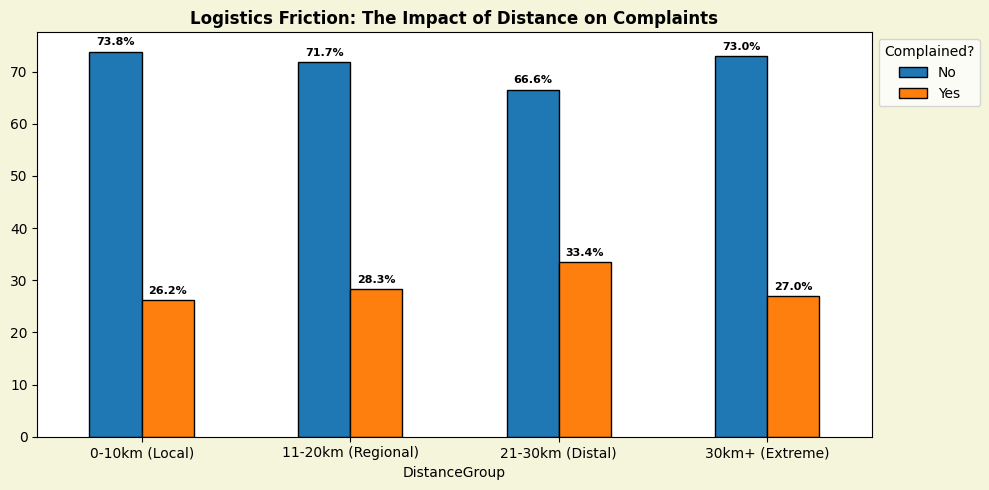

In [ ]:
distance_complain = pd.crosstab(df.DistanceGroup, df.Complain, normalize = 'index') * 100
fig, ax = plt.subplots(figsize = (10, 5), facecolor = 'beige')
distance_complain.plot(kind = 'bar', ax = ax, edgecolor = 'black')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding = 3, fontsize=8, fontweight='bold')
plt.legend(title = "Complained?", labels = ['No', 'Yes'], bbox_to_anchor = (1, 1))
plt.xticks(rotation = 0)
plt.title("Logistics Friction: The Impact of Distance on Complaints", weight = 'bold')
plt.tight_layout()
plt.savefig('../figures/complain_distance.png', dpi=300, bbox_inches='tight')
plt.show()

**Logistic Friction: The Impact of Distance on Customer Complaints**


* **The Distal Bottleneck:** The highest complaint rate is observed in the **21-30km (Distal)** group. Approximately **one-third of customers** in this zone report an issue, which is significantly higher than in the Local or Regional zones.

* **The "Extreme" Anomaly:** Interestingly, the complaint rate slightly drops in the **30km+ (Extreme)** category compared to the Distal group. This might suggest that customers living very far away have lower expectations for delivery speed, or that the company uses different, perhaps more reliable third-party carriers for extreme distances.

**Conclusion for Management:**
The delivery process encounters significant issues when crossing the 20km mark. Since we previously identified that **Mobile Phones** are a high-churn category, there is a strong possibility that high-value, fragile electronics are being damaged or delayed specifically during these mid-to-long-range Distal deliveries.

<u>**Strategic Recommendation:**</u>
We should audit the delivery partners or internal logistics protocols used for the **21-30km (Distal)** zone. Implementing "White Glove" delivery or improved protective packaging for the **Mobile Phones** category in this specific distance range could drastically reduce the 30%+ complaint rate.


#### **Final Executive Summary. Strategic Roadmap for Churn Reduction**




**1. Fix the "First-Month Friction"**

Our analysis revealed a **53.4% churn rate** within the first month of tenure. This is the single biggest revenue leak.

* **Insight:** Retention is binary; if a customer passes the 6-month mark, their loyalty becomes nearly 100%.

* **Action:** Redirect the loyalty budget from long-term members to an **Aggressive 30-day Onboarding Program.** A 10% improvement here significantly boosts the long-term Customer Lifetime Value (CLV).

**2. Optimize High-Risk Logistics Zones**

The **21-30km (Distal) zone** is a "danger zone" where complaints spike to **33.4%**, specifically affecting high-value **Mobile Phone** orders.

* **Insight:** The current logistics model fails at mid-to-long distances for fragile electronics.

* **Action:** Implement "White Glove" delivery protocols and reinforced packaging for electronics in the 20km+ range. This targets the root cause of the most vocal churners.

**3. Leverage the "Cashback Buffer" for Service Recovery**

There is a clear **$25.00 gap** in compensation between customers who stay and those who leave after a complaint.

 * **Insight:** Financial incentives act as a stronger retention tool than subjective satisfaction scores. "Satisfied" customers (rated 4-5) still churn if the compensation for a mistake is insufficient.

* **Action:** Standardize a **high-touch recovery protocol** for all formal complaints. Increasing the cashback threshold to a median of **$175+** for reported issues will statistically "flip" the churn decision for at least **32.8%** of at-risk users.

### The General Customer

#### Marital Status and Customer Satisfaction Analysis



The following visualization examines the relationship between a customer's marital status and their reported satisfaction levels, normalized by group to provide a direct percentage-based comparison.

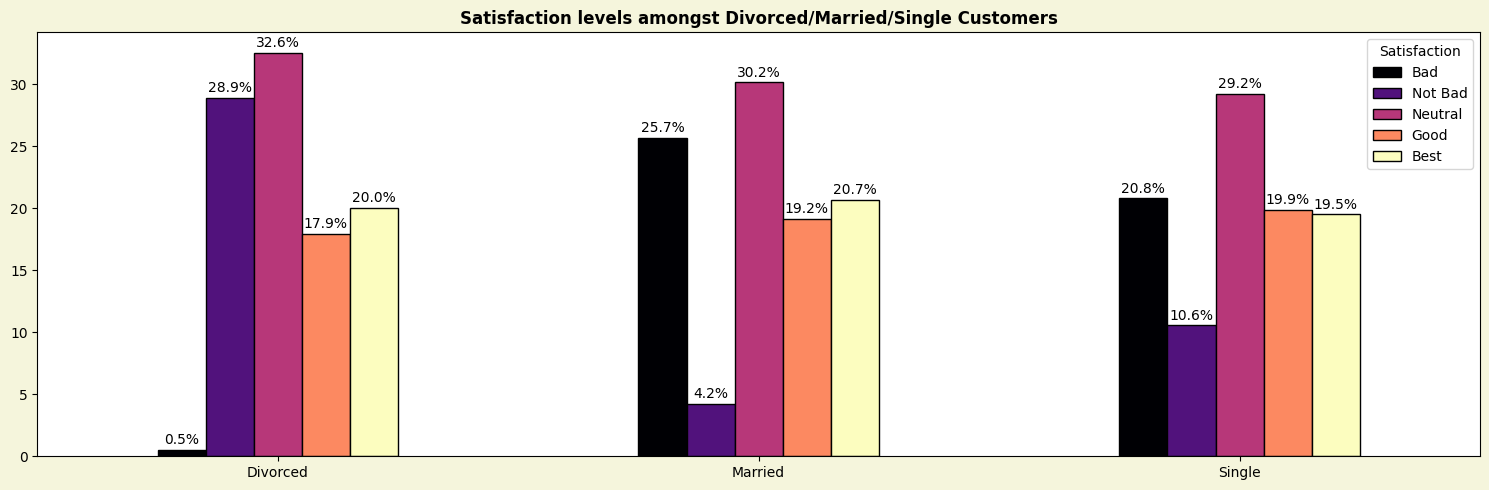

In [ ]:
# Marital Status vs. Satisfaction
order = ['Best', 'Good', 'Neutral', 'Not Bad', 'Bad']
marital_satisfaction = (pd.crosstab(df.MaritalStatus, df.Satisfaction, normalize = 'index') * 100).reindex(columns = order[::-1]) 
fig, ax = plt.subplots(figsize = (15, 5), facecolor = 'beige')
marital_satisfaction.plot(kind = 'bar', colormap = 'magma', ax = ax, edgecolor = 'black')
for container in ax.containers:
    ax.bar_label(container, fmt = '%1.1f%%', padding = 2)
plt.title("Satisfaction levels amongst Divorced/Married/Single Customers", weight = 'bold')
plt.xticks(rotation = 0)
plt.xlabel("")
plt.tight_layout()
plt.savefig('../figures/marital_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()


<u>**Key Conclusions:**</u>

* **Married Customers are the Least Content:** This group shows a significant spike in negative sentiment, with **25.7%** reporting a "Bad" experience; the highest across all demographics, while only **4.2%** fall into the "Not Bad" category.

* **Divorced Customers are the Least Critical:** Interestingly, almost no divorced customers **(0.5%)** rated their experience as "Bad," and they show the highest combined "Best" and "Good" satisfaction scores at nearly **38%**.

* **Neutrality Across the Board:** Regardless of status, "Neutral" remains the most common sentiment (averaging around **30%**), suggesting that for a large portion of the customer base, the current service or product does not evoke a strong emotional response.

#### Preferred Order Category Analysis by Marital Status

This section examines how customer purchasing preferences shift across different marital statuses. By normalizing the data into percentages, we can directly compare which product categories are most popular within each demographic group regardless of their total population size.

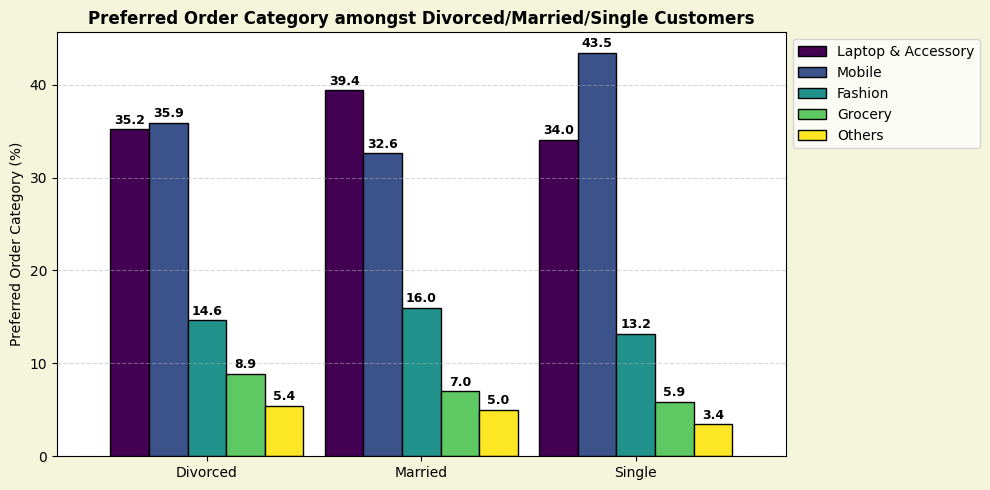

In [ ]:
ms_cat = pd.crosstab(df.MaritalStatus, df.PreferedOrderCat, normalize = 'index').reindex(columns = df.PreferedOrderCat.value_counts().index) * 100
fig, ax = plt.subplots(figsize = (10, 5), facecolor = 'beige')
ms_cat.plot(kind = 'bar', ax = ax, colormap = 'viridis', width = .9, edgecolor = 'black')
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f", padding = 2, size = 9, weight = 'bold')
plt.xticks(rotation = 0)
plt.xlabel("")
plt.ylabel("Preferred Order Category (%)")
plt.title("Preferred Order Category amongst Divorced/Married/Single Customers", weight = 'bold')
plt.grid(axis = 'y', linestyle = '--', alpha = .5)
plt.legend(bbox_to_anchor = (1, 1))
plt.tight_layout()
plt.savefig('../figures/marital_category.png', dpi=300, bbox_inches='tight')
plt.show()

<u>**Key Conclusions:**</u>

* **Tech Dominance Across All Groups:** Electronics (Laptops, Accessories, and Mobile phones) represent the vast majority of orders for every segment, consistently making up over **65%** of the total preference across Divorced, Married, and Single customers.

* **Married Customers Prioritize Computing:** Married individuals show the highest preference for "Laptop & Accessory" at **39.4%**, whereas Single customers are more likely to prioritize "Mobile" devices (**43.5%**).

* **Niche Category Consistency:** Lifestyle categories like "Fashion," "Grocery," and "Others" follow a similar descending order of importance for all groups, with Fashion consistently holding the third spot, peaking at **16.0%** among married customers.

 #### Customer Churn Analysis by Marital Status

This analysis visualizes the churn rate (the percentage of customers who stop using the service) across different marital status groups. By normalizing the data, we can identify which demographic segment poses the highest risk of attrition and requires more aggressive retention strategies.

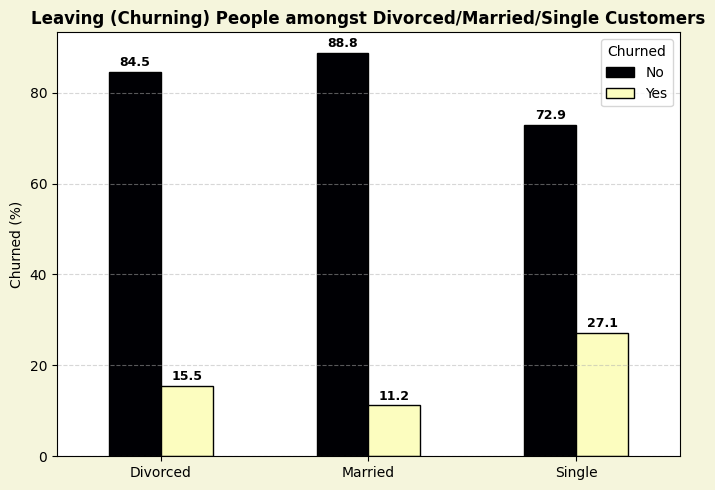

In [ ]:
ms_churn = pd.crosstab(df.MaritalStatus, df.Churn, normalize = 'index') * 100
fig, ax = plt.subplots(figsize = (7, 5), facecolor = 'beige')
ms_churn.plot(kind = 'bar', ax = ax, colormap = 'magma', edgecolor = 'black')
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f", padding = 2, size = 9, weight = 'bold')
plt.xticks(rotation = 0)
plt.xlabel("")
plt.ylabel("Churned (%)")
plt.title("Leaving (Churning) People amongst Divorced/Married/Single Customers", weight = 'bold')
plt.grid(axis = 'y', linestyle = '--', alpha = .5)
plt.legend(bbox_to_anchor = (1, 1), title = 'Churned', labels = ['No', 'Yes'])
plt.tight_layout()
plt.savefig('../figures/marital_churn.png', dpi=300, bbox_inches='tight')
plt.show()

<u>**Key Conclusions:**</u>
* **Single Customers are High Risk:** The "Single" segment shows the highest churn rate by a significant margin at **27.1%**. This is nearly double the rate of divorced customers and more than double that of married customers.

* **Married Customers are the Most Loyal:** Married individuals exhibit the highest retention levels, with **88.8%** remaining with the service and only **11.2%** churning. This suggests that this demographic finds the most long-term value in the current offerings.

* **Significant Retention Gap:** There is a **15.9** percentage point difference in churn between single and married customers. This indicates that lifecycle stages are a major predictor of customer loyalty, and targeted intervention for the single demographic is likely necessary to stabilize the user base.

#### Complaint Analysis by Marital Status

This visualization explores the frequency of formal complaints filed by customers, categorized by their marital status. By observing the percentage of "Yes" responses across these groups, we can determine if specific life stages are associated with higher levels of dissatisfaction or more active feedback behavior.

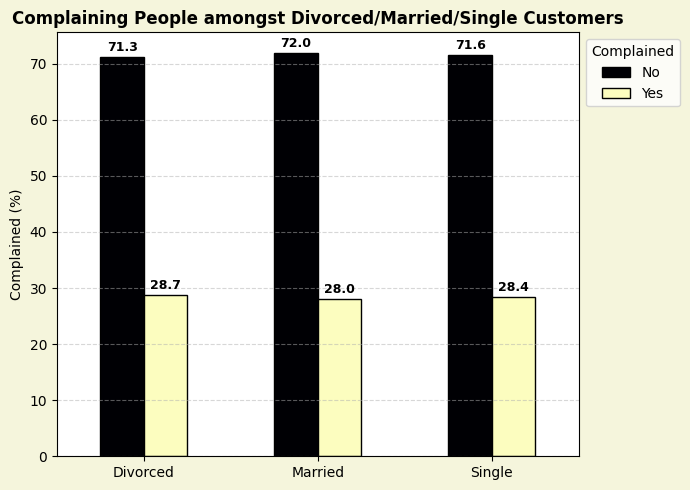

In [ ]:
ms_complain = pd.crosstab(df.MaritalStatus, df.Complain, normalize = 'index') * 100
fig, ax = plt.subplots(figsize = (7, 5), facecolor = 'beige')
ms_complain.plot(kind = 'bar', ax = ax, colormap = 'magma', edgecolor = 'black')
for container in ax.containers:
    ax.bar_label(container, fmt = "%.1f", padding = 2, size = 9, weight = 'bold')
plt.xticks(rotation = 0)
plt.xlabel("")
plt.ylabel("Complained (%)")
plt.title("Complaining People amongst Divorced/Married/Single Customers", weight = 'bold')
plt.grid(axis = 'y', linestyle = '--', alpha = .5)
plt.legend(bbox_to_anchor = (1, 1), title = 'Complained', labels = ['No', 'Yes'])
plt.tight_layout()
plt.savefig('../figures/marital_complain.png', dpi=300, bbox_inches='tight')
plt.show()

<u>**Key Conclusions:**</u>
* **Uniform Complaint Behavior:** Unlike churn or product preference, complaint rates are remarkably consistent across all demographics, hovering steadily between **28.0%** and **28.7%**.

* **No Significant Demographic Correlation:** Marital status does not appear to be a driving factor for filing complaints, as the variance between the highest group (Divorced at **28.7%**) and the lowest group (Married at **28.0%**) is only **0.7** percentage points.

* **High General Resolution Opportunity:** Across all three segments, nearly **3 out of 10** customers have filed a complaint, indicating a universal baseline of service issues that affects the entire customer base regardless of their personal status.

#### Heatmap Analysis: The Distance-Satisfaction Paradox

This heatmap cross-references customer satisfaction with warehouse distance to identify specific "Churn Hotspots." Using the **Magma** colormap, we can visualize the intensity of attrition across different segments.

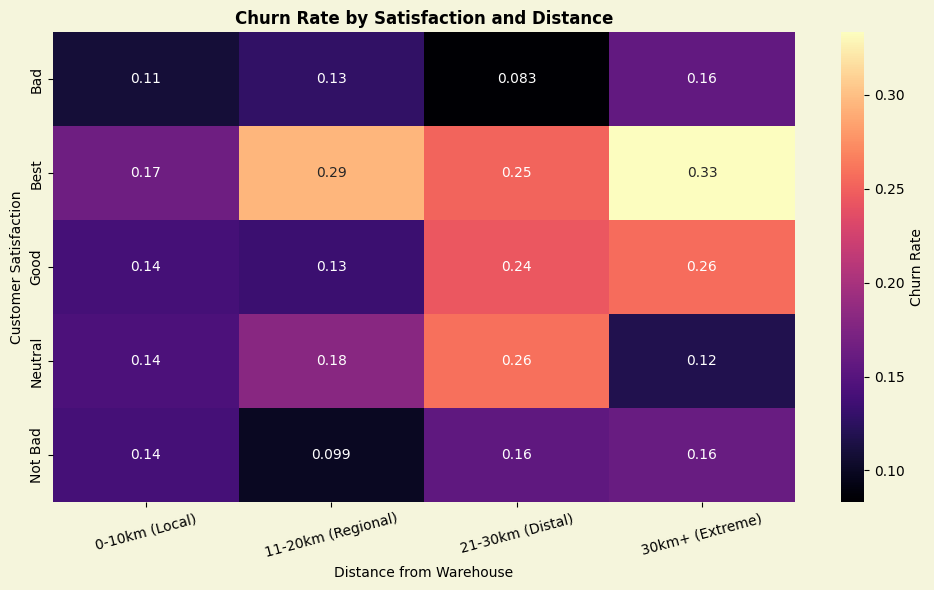

In [ ]:
pivot = df.pivot_table(index='Satisfaction', columns='DistanceGroup', values='Churn', aggfunc='mean')
fig = plt.figure(figsize = (10, 6), facecolor = 'beige')
sns.heatmap(pivot, annot=True, cmap='magma', cbar_kws={'label': 'Churn Rate'})
plt.xticks(rotation = 15)
plt.ylabel('Customer Satisfaction')
plt.xlabel('Distance from Warehouse')
plt.title("Churn Rate by Satisfaction and Distance", weight='bold')
plt.tight_layout()
plt.savefig('../figures/churn_satisfaction_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

<u>**Interpretation & Strategic Insights:**</u>

* **Color Intensity (Magma Scale):** Darker regions (black/purple) indicate high retention, while the brightest regions (orange/yellow) represent the highest churn probability.

* **The "High-Expectation" Friction:** Contrary to intuition, the highest churn rates are concentrated among customers who rated the service as **"Best"** or **"Good"** but live in **Regional, Distal, or Extreme** zones. This suggests that high satisfaction does not guarantee loyalty if logistical delays (caused by distance) interfere with the premium experience these customers expect.

* **Neutral Zone Vulnerability:** Customers with a **"Neutral"** rating also show a significant churn spike in the **Distal (21-30km)** range. Being "passives," these users have low emotional resistance to delivery friction and are easily swayed by competitors.

* **The Low-Rating Retention Paradox:** Interestingly, the **"Bad"** and **"Not Bad"** segments show darker colors (lower churn) across most distances compared to the "Best" group. This may indicate that customers with low expectations are paradoxically more "sticky," or that our current service recovery efforts are effectively targeting the unhappiest users while neglecting the "happy but distant" ones.

* **Strategic Conclusion:** High satisfaction is fragile. The company is losing its most positive-leaning customers due to distance-related friction. Improving the delivery experience for the **20km+ zone** is not just about fixing complaints, it is about protecting our highest-rated customer segments.

## **Final Executive Summary & Strategic Roadmap**


**1. Key Insights (The "Why")**

* **Onboarding Crisis:** Churn peaks at **53.4%** in the first month. Retention is binary: survival of the first 6 months leads to near-permanent loyalty.

* **The Distance Paradox:** High-satisfaction customers **(Best/Good)** are the most likely to churn when living in **Distal/Extreme zones (20km+)**. Logistics friction outweighs brand sentiment for this segment.

* **Service Recovery Gap:** **$25 difference** in Cashback is the tipping point between retention and churn.

* **Demographic Risk:** **Single customers** are high-risk (**27.1%** churn), prioritizing Mobile tech, while Married customers are stable but demand better Laptop/Accessory support.

**2. Strategic Actions (The "How")**

1. **Phase 1 (Immediate):** Launch a **High-Touch 30-Day Onboarding Program** to bridge the initial loyalty gap.

2. **Phase 2 (Operational):** Implement **"White-Glove" delivery** and reinforced packaging for **Mobile Phones** in the 21-30km delivery range.

3. **Phase 3 (Financial):** Standardize a **$175+ median Cashback recovery** for formal complaints to "buy back" loyalty.

4. **Phase 4 (Marketing):** Segment promotions by lifecycle: **Mobile focus** for Singles, **Home Office bundles** for Married segments.